# Лабораторная работа 6. Сегментация дорожных знаков

## 1. Зависимости и параметры

In [1]:
from pathlib import Path
import io
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import (
    deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights,
)
from torchvision.transforms import functional as TF
from PIL import Image, ImageDraw
from IPython.display import Image as DisplayImage, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path.cwd() if Path('lab6.ipynb').exists() else Path.cwd() / 'lab6'
DATA_ROOT = ROOT / 'data/sign_dataset'
CHECKPOINT = ROOT / 'runs/deeplab_binary/best.pt'
IMAGE_SIZE = (256, 448)
EPOCHS = 5
BATCH_SIZE = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
print('Устройство:', DEVICE)

Устройство: mps


## 2. Подготовка датасета

In [2]:
def annotation_mask(item, size):
    mask = Image.new('L', size, 0)
    draw = ImageDraw.Draw(mask)
    regions = item.get('regions', {})
    regions = regions.values() if isinstance(regions, dict) else regions
    for region in regions:
        if region.get('region_attributes', {}).get('name') not in (None, '', 'road sign'):
            continue
        s = region['shape_attributes']
        if s['name'] == 'polygon':
            points = list(zip(s['all_points_x'], s['all_points_y']))
            if len(points) >= 3:
                draw.polygon(points, fill=1)
        elif s['name'] in ('ellipse', 'circle'):
            rx, ry = s.get('rx', s.get('r')), s.get('ry', s.get('r'))
            draw.ellipse((s['cx']-rx, s['cy']-ry, s['cx']+rx, s['cy']+ry), fill=1)
        elif s['name'] == 'rect':
            x, y = s['x'], s['y']
            draw.rectangle((x, y, x+s['width'], y+s['height']), fill=1)
    return mask

def resize_box(size):
    width, height = size
    out_h, out_w = IMAGE_SIZE
    scale = min(out_w / width, out_h / height)
    w, h = round(width * scale), round(height * scale)
    left, top = (out_w-w)//2, (out_h-h)//2
    return left, top, left+w, top+h

def prepare_image(image):
    left, top, right, bottom = resize_box(image.size)
    canvas = Image.new('RGB', IMAGE_SIZE[::-1], (124, 116, 104))
    canvas.paste(image.resize((right-left, bottom-top), Image.Resampling.BILINEAR), (left, top))
    return TF.normalize(TF.to_tensor(canvas), MEAN, STD)

class RoadSignsDataset(Dataset):
    def __init__(self, split, augment=False):
        self.folder = DATA_ROOT / split
        annotations = json.loads((self.folder / 'via_region_data.json').read_text())
        self.items = sorted(annotations.values(), key=lambda item: item['filename'])
        self.augment = augment

    def __len__(self):
        return len(self.items)

    def original(self, index):
        item = self.items[index]
        image = Image.open(self.folder / item['filename']).convert('RGB')
        return image, annotation_mask(item, image.size), item['filename']

    def __getitem__(self, index):
        image, mask, _ = self.original(index)
        left, top, right, bottom = resize_box(image.size)
        target = Image.new('L', IMAGE_SIZE[::-1], 255)
        target.paste(mask.resize((right-left, bottom-top), Image.Resampling.NEAREST), (left, top))
        tensor = prepare_image(image)
        target = torch.from_numpy(np.asarray(target, dtype=np.int64).copy())
        if self.augment and random.random() < 0.5:
            tensor, target = tensor.flip(-1), target.flip(-1)
        return tensor, target

train_set = RoadSignsDataset('train', augment=True)
val_set = RoadSignsDataset('val')
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

def validation_samples():
    for index in range(len(val_set)):
        yield val_set.original(index)

display(pd.DataFrame({'Часть': ['train', 'validation'], 'Изображений': [len(train_set), len(val_set)]}))

,Часть,Изображений
0,train,2054
1,validation,127


## 3. Метрики

In [3]:
def calc_metrics(target, prediction):
    target, prediction = np.asarray(target)>0, np.asarray(prediction)>0
    assert target.shape == prediction.shape
    tp = np.count_nonzero(target & prediction)
    fp = np.count_nonzero(~target & prediction)
    fn = np.count_nonzero(target & ~prediction)
    return {
        'IoU': tp / (tp+fp+fn+1e-9),
        'Precision': tp / (tp+fp+1e-9),
        'Recall': tp / (tp+fn+1e-9),
        'L2': float(np.sqrt(fp+fn)),
        'RMSE': float(np.sqrt((fp+fn)/target.size)),
    }

def summarize(frame):
    result = {'Изображений': len(frame), **frame[['IoU', 'Precision', 'Recall', 'L2', 'RMSE']].mean().to_dict()}
    for threshold in [0.5, 0.75, 0.9]:
        result[f'IoU ≥ {threshold}, %'] = 100 * (frame['IoU'] >= threshold).mean()
    return result

@torch.no_grad()
def predict_mask(model, image):
    tensor = prepare_image(image).unsqueeze(0).to(DEVICE)
    logits = model(tensor)['out']
    left, top, right, bottom = resize_box(image.size)
    logits = logits[:, :, top:bottom, left:right]
    logits = nn.functional.interpolate(logits, size=(image.height, image.width), mode='bilinear', align_corners=False)
    return logits.argmax(1)[0].cpu().numpy().astype('uint8')

@torch.no_grad()
def evaluate(model, samples, n_examples=0):
    model.eval()
    rows, examples = [], []
    for image, target, name in samples:
        prediction = predict_mask(model, image)
        rows.append({'Фото': name, **calc_metrics(target, prediction)})
        if len(examples) < n_examples:
            examples.append((image, np.asarray(target)>0, prediction, name))
    return pd.DataFrame(rows), examples

## 4. Обучение модели

In [4]:
def build_model(pretrained=True):
    weights = DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
    model = deeplabv3_mobilenet_v3_large(weights=weights, weights_backbone=None)
    model.classifier[-1] = nn.Conv2d(256, 2, kernel_size=1)
    model.aux_classifier = None
    for index, block in model.backbone.named_children():
        for parameter in block.parameters():
            parameter.requires_grad = int(index) >= 11
    return model.to(DEVICE)

model = build_model(pretrained=not CHECKPOINT.exists())
best_iou = -1.0
if CHECKPOINT.exists():
    saved = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
    assert tuple(saved['image_size']) == IMAGE_SIZE
    model.load_state_dict(saved['model'])
    previous, _ = evaluate(model, validation_samples())
    best_iou = previous['IoU'].mean()
    print(f'IoU сохранённой модели: {best_iou:.4f}')

optimizer = torch.optim.AdamW([
    {'params': model.classifier.parameters(), 'lr': 1e-4},
    {'params': [p for p in model.backbone.parameters() if p.requires_grad], 'lr': 3e-5},
], weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([0.1, 1.0], device=DEVICE), ignore_index=255)
CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)

IoU сохранённой модели: 0.2952


In [5]:
history = []
for epoch in range(1, EPOCHS+1):
    model.train()
    model.backbone.eval()
    losses = []
    for images, targets in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(images.to(DEVICE))['out'], targets.to(DEVICE))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    val_frame, _ = evaluate(model, validation_samples())
    val_iou = val_frame['IoU'].mean()
    history.append({'Эпоха': epoch, 'Loss': np.mean(losses), 'Validation IoU': val_iou})
    updated = np.isfinite(val_iou) and val_iou > best_iou
    if updated:
        best_iou = val_iou
        torch.save({'model': model.state_dict(), 'image_size': IMAGE_SIZE}, CHECKPOINT)
    print(f"Эпоха {epoch}/{EPOCHS}: loss={np.mean(losses):.4f}, IoU={val_iou:.4f}" + (' — best обновлён' if updated else ''), flush=True)

model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)['model'])
model.eval();

Эпоха 1/5: loss=0.0493, IoU=0.3185 — best обновлён


Эпоха 2/5: loss=0.0384, IoU=0.3445 — best обновлён


Эпоха 3/5: loss=0.0352, IoU=0.3392


Эпоха 4/5: loss=0.0318, IoU=0.3495 — best обновлён


Эпоха 5/5: loss=0.0296, IoU=0.3679 — best обновлён


,Эпоха,Loss,Validation IoU
0,1,0.0493,0.3185
1,2,0.0384,0.3445
2,3,0.0352,0.3392
3,4,0.0318,0.3495
4,5,0.0296,0.3679


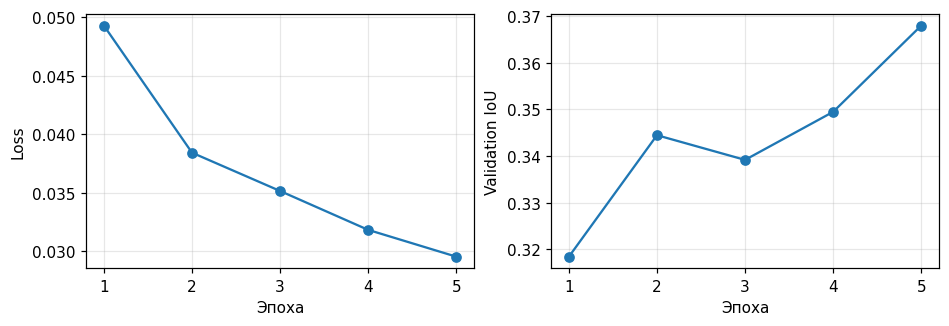

In [6]:
def show_figure(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format='png', dpi=110, bbox_inches='tight')
    display(DisplayImage(data=buffer.getvalue()))
    plt.close(figure)

history_df = pd.DataFrame(history)
display(history_df.round(4))
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for axis, column in zip(axes, ['Loss', 'Validation IoU']):
    axis.plot(history_df['Эпоха'], history_df[column], marker='o')
    axis.set(xlabel='Эпоха', ylabel=column)
    axis.grid(alpha=0.3)
show_figure(fig)

## 5. Оценка на validation и фотографиях

In [7]:
def photo_samples():
    photos = sorted((ROOT / 'own_photos').glob('*.png'))
    assert len(photos) == 10
    for path in photos:
        image = Image.open(path).convert('RGB')
        mask = Image.open(ROOT / 'own_masks' / path.name).convert('L')
        assert image.size == mask.size
        yield image, mask, path.name

val_results, val_examples = evaluate(model, validation_samples(), n_examples=6)
photo_results, photo_examples = evaluate(model, photo_samples(), n_examples=10)
results = pd.DataFrame([summarize(val_results), summarize(photo_results)], index=['Validation', '10 фото'])
display(results.T.round(4))
display(photo_results.round(4))

,Validation,10 фото
Изображений,127.0000,10.0000
IoU,0.3679,0.4328
Precision,0.4216,0.5250
Recall,0.7302,0.8144
L2,120.2414,102.7244
RMSE,0.0873,0.1248
"IoU ≥ 0.5, %",25.1969,40.0000
"IoU ≥ 0.75, %",1.5748,0.0000
"IoU ≥ 0.9, %",0.0000,0.0000


,Фото,IoU,Precision,Recall,L2,RMSE
0,01.png,0.4656,0.5211,0.8139,106.0424,0.1112
1,02.png,0.4278,0.6785,0.5366,86.3539,0.0900
2,03.png,0.5913,0.6238,0.9189,98.8383,0.1117
3,04.png,0.2795,0.2795,1.0000,62.8411,0.1149
4,05.png,0.3530,0.3530,1.0000,68.2862,0.1265
5,06.png,0.1982,0.6094,0.2271,132.0795,0.0917
6,07.png,0.7478,0.8211,0.8934,106.7567,0.1483
7,08.png,0.5161,0.5966,0.7927,148.9429,0.2069
8,09.png,0.0854,0.0854,1.0000,89.6549,0.0934
9,10.png,0.6634,0.6817,0.9610,127.4480,0.1533


## 6. Примеры предсказаний

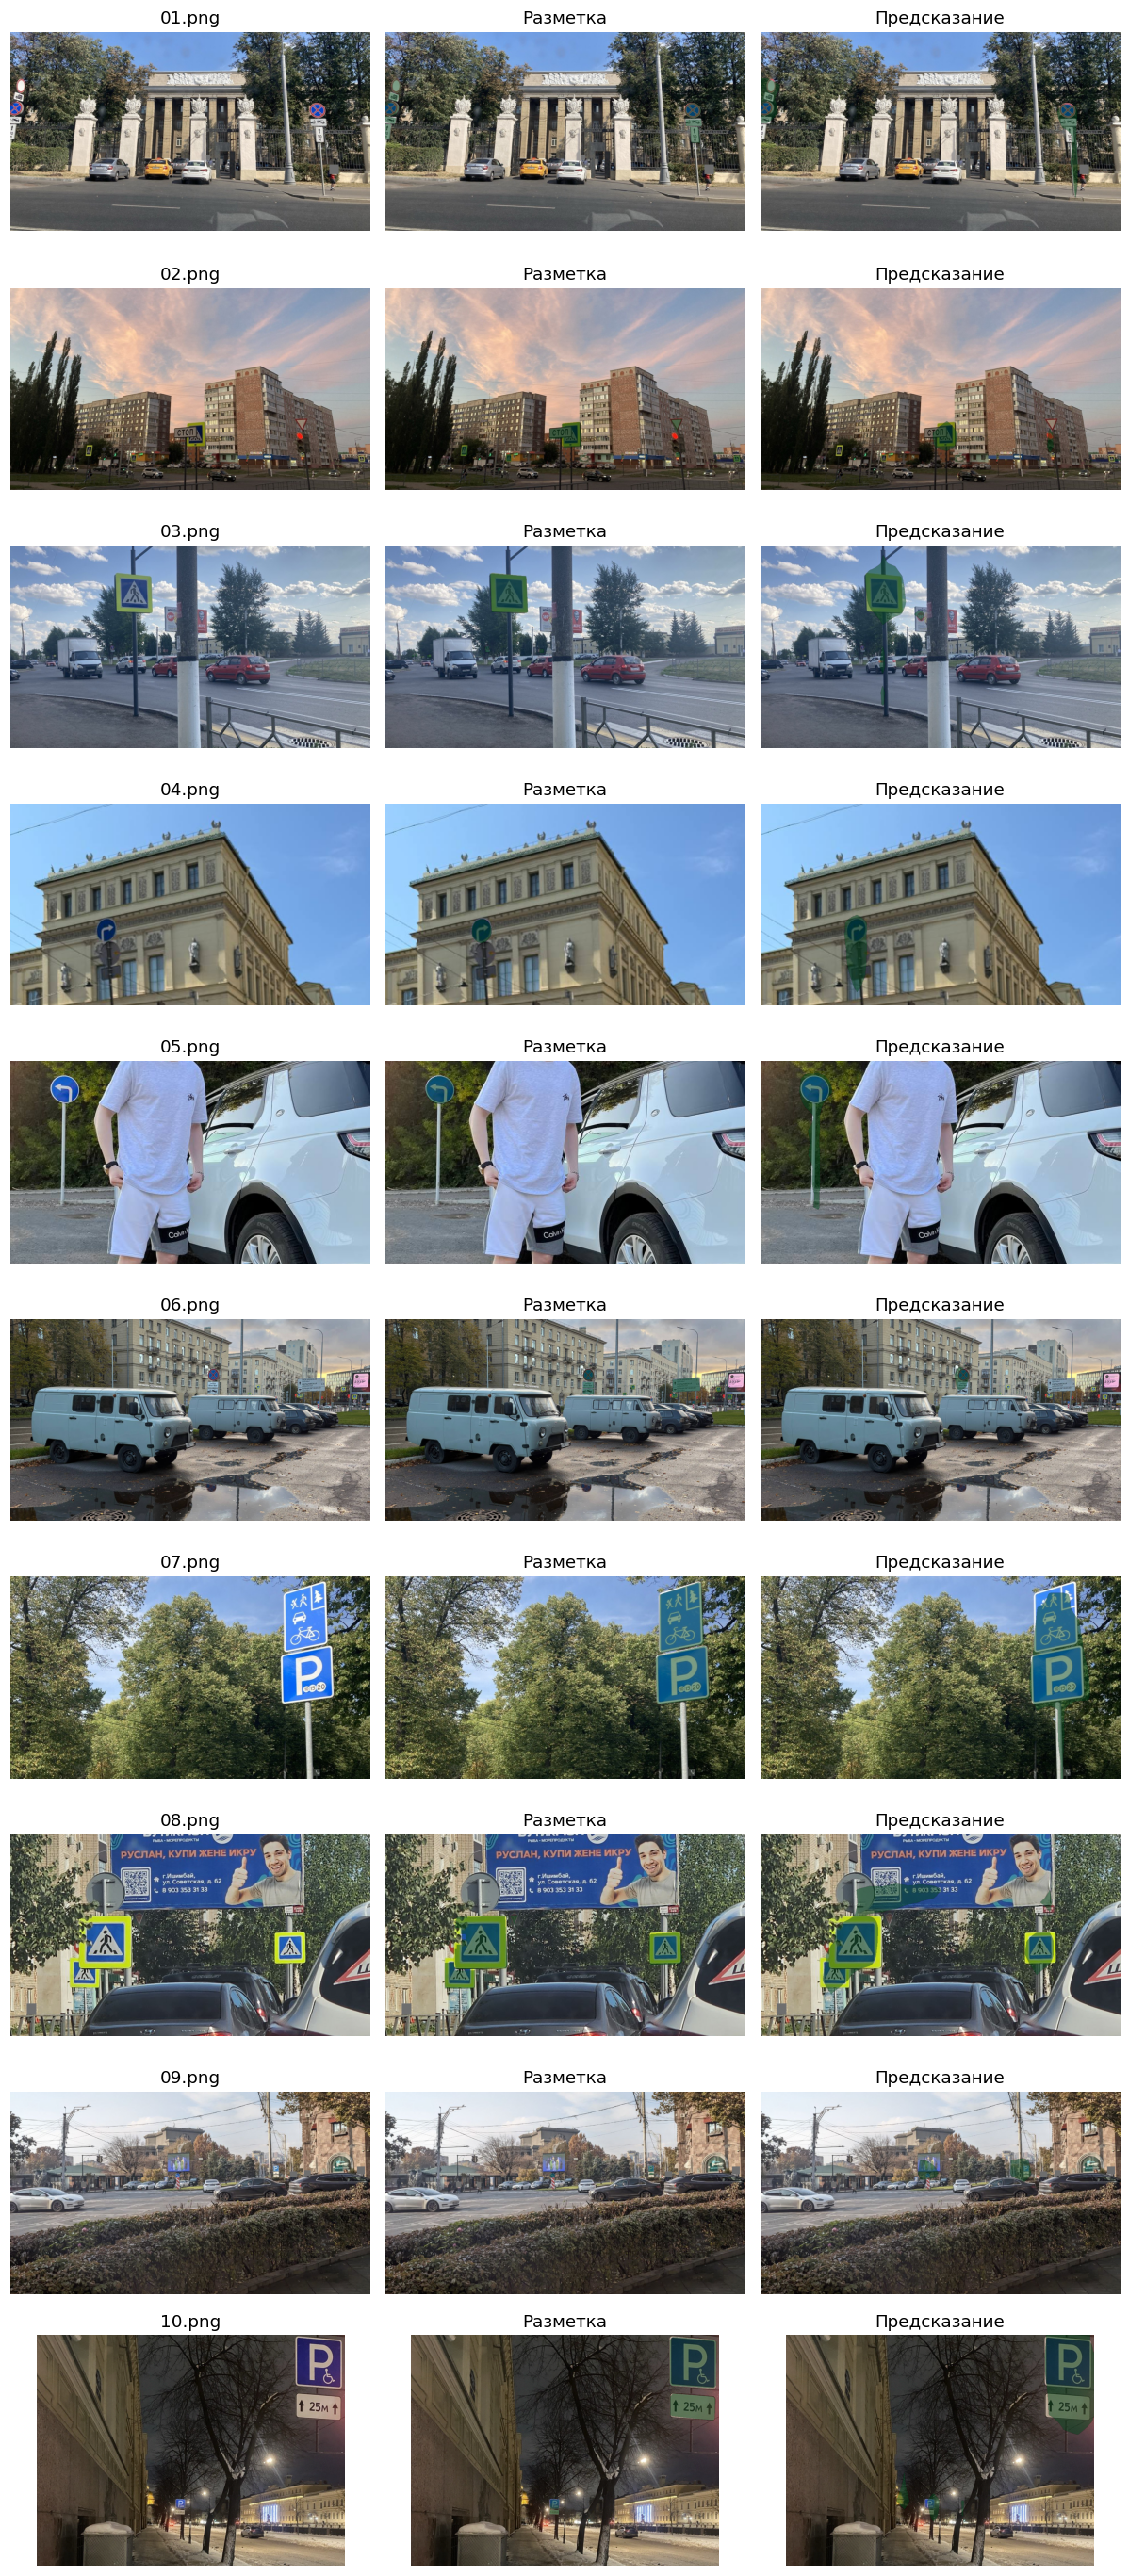

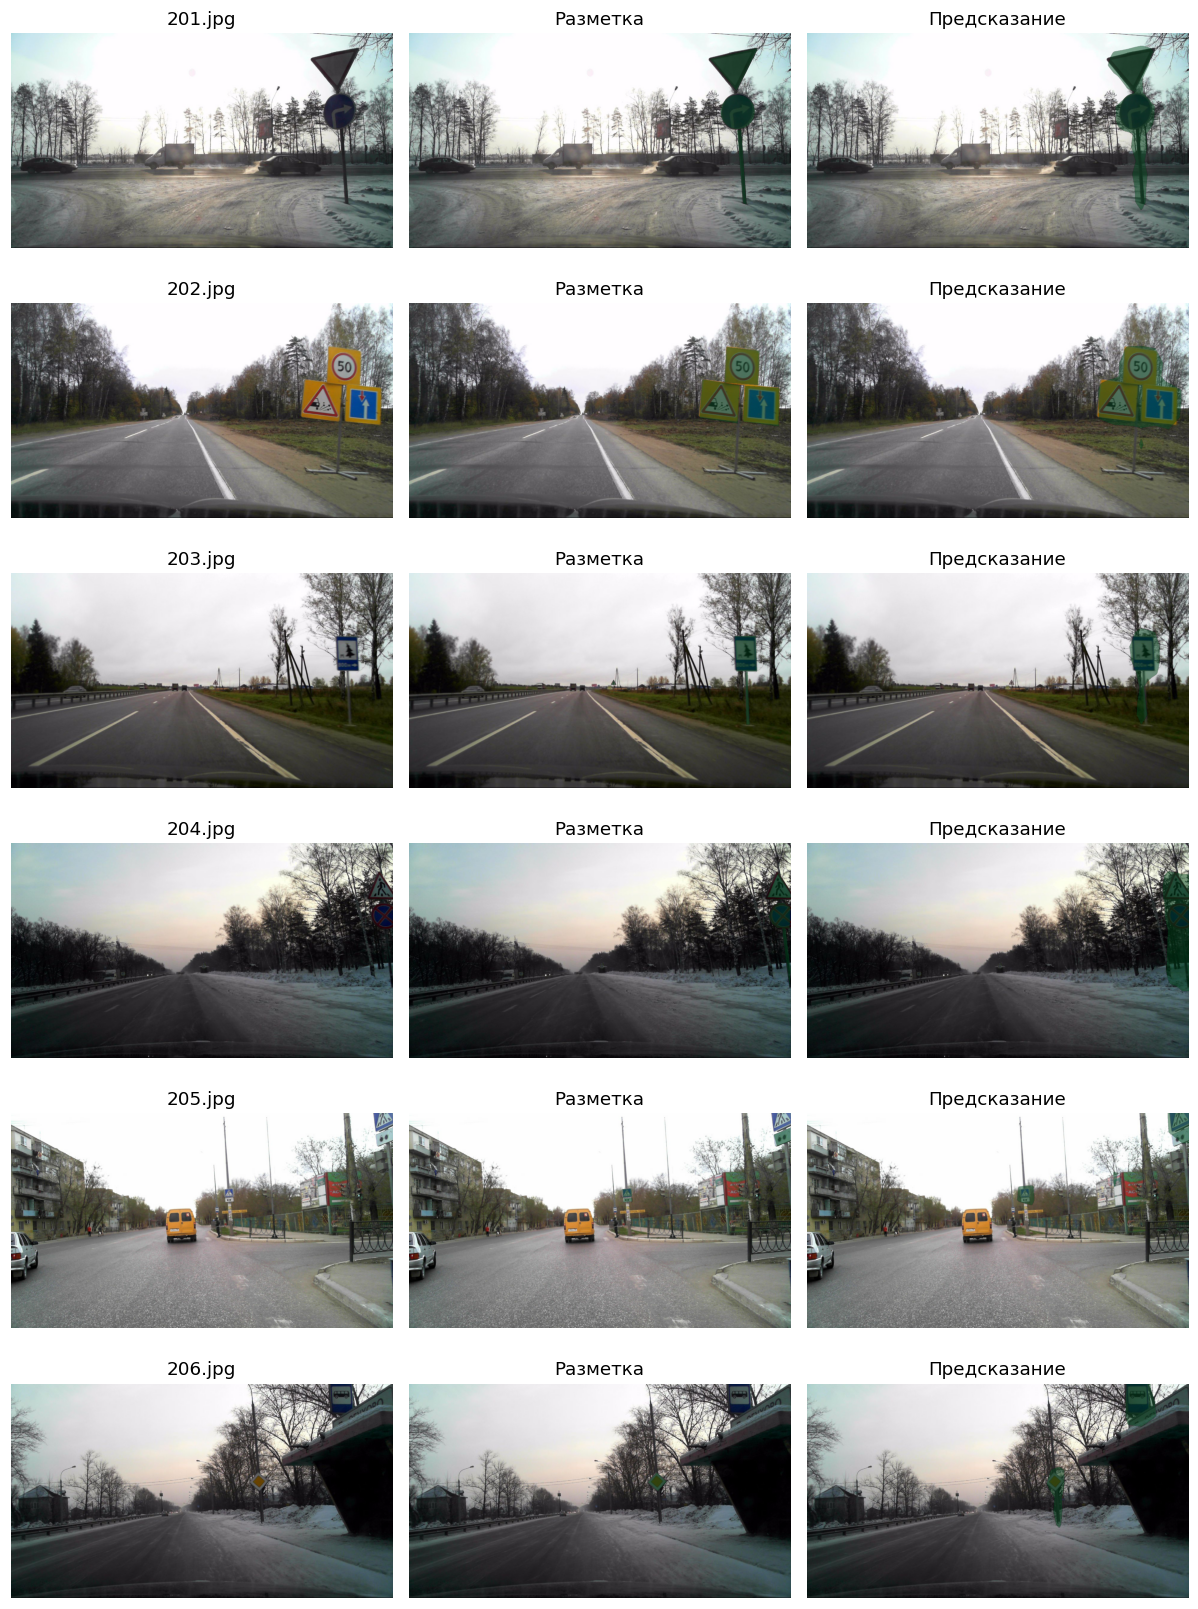

In [8]:
def show_predictions(examples):
    fig, axes = plt.subplots(len(examples), 3, figsize=(11, 2.5*len(examples)), squeeze=False)
    for row, (image, target, prediction, name) in zip(axes, examples):
        row[0].imshow(image)
        row[0].set_title(name)
        for axis, mask, title in [(row[1], target, 'Разметка'), (row[2], prediction, 'Предсказание')]:
            axis.imshow(image)
            axis.imshow(np.ma.masked_where(mask == 0, mask), cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            axis.set_title(title)
        for axis in row:
            axis.axis('off')
    fig.tight_layout()
    show_figure(fig)

show_predictions(photo_examples)
show_predictions(val_examples)